In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
import pmdarima as pm
import itertools

In [23]:
df=pd.read_csv("../data/clean_monthly_average_data/monthly_ams_aqi.csv", index_col=['date'],parse_dates=['date'])


<Axes: xlabel='date'>

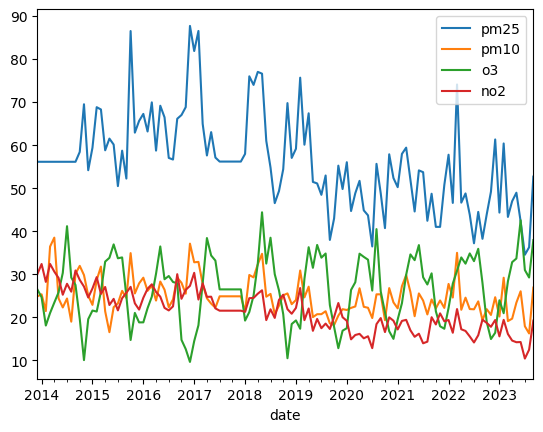

In [4]:
df.shape
df.plot()

In [ ]:
df.describe()

In [45]:
df.head()

,pm25,pm10,o3,no2
date,,,,
2013-12-31,56.13,24.85,26.47,30.00
2014-01-31,56.13,25.33,24.64,32.37
2014-02-28,56.13,21.43,18.07,28.21
2014-03-31,56.13,36.42,20.97,32.39
2014-04-30,56.13,38.50,23.40,30.60


In [ ]:
df.plot()

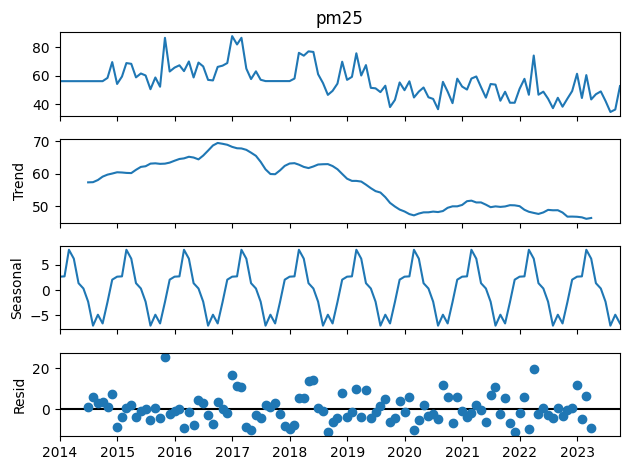

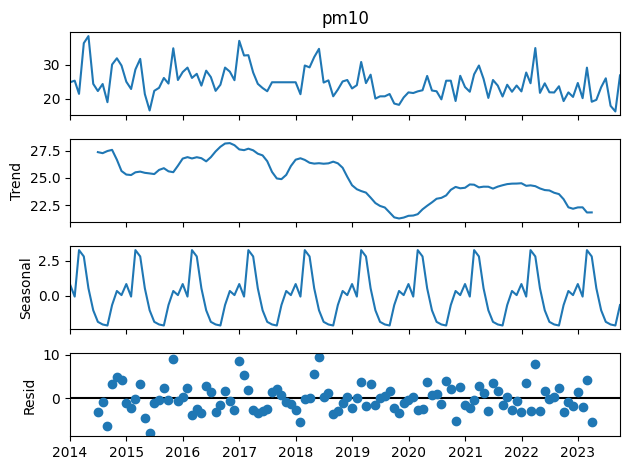

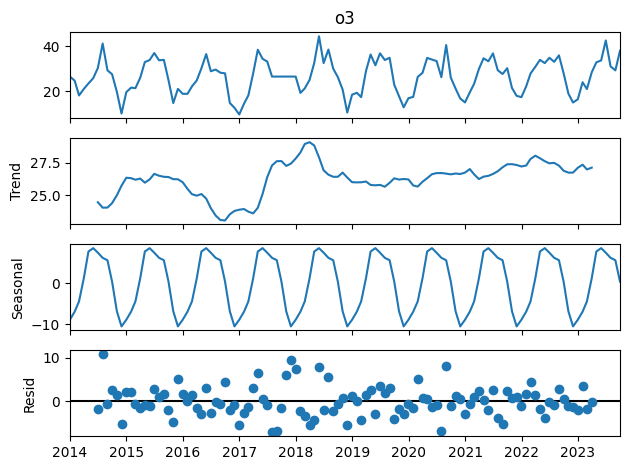

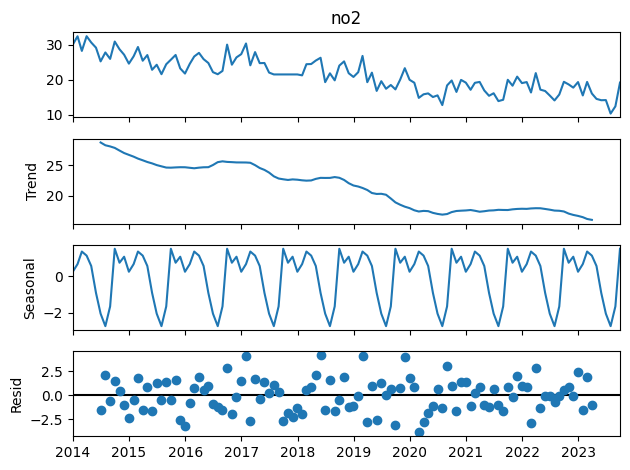

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
for column in df.columns:
    result = seasonal_decompose(df[column])
    result.plot()
    plt.show()

In [ ]:
df.dtypes

In [10]:
df2=df.copy()

In [11]:
df1=df.copy()

In [13]:
pollutants = df.columns
dataframes = dict()
for pollutant in pollutants:
    dfp = df[[pollutant]].copy()
    dfp[f'Last_year_{pollutant}']=df1[pollutant].shift(12)
    dfp[f'Increase_{pollutant}'] = df1[pollutant] - df1[f'Last_year_{pollutant}']
    dataframes[pollutant] = dfp
    

print(dataframes)
df1.tail()

KeyError: 'Last_year_pm25'

In [12]:
y = df2['pm25']
train_size = int(len(y) * 0.6)
train, test = y[0:train_size], y[train_size:len(y)]

In [14]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    if result[1] <= 0.05:
        print("Data is stationary")
    else:
        print("Data is not stationary")
        return False
    return True

In [15]:
if not check_stationarity(train):
    train_diff = train.diff().dropna()
    if not check_stationarity(train_diff):
        print("Differencing did not make the series stationary. Consider using higher order differencing or transformations.")

Data is not stationary
Data is stationary


In [ ]:
best_aic = np.inf 
best_order = None
best_model = None

In [ ]:
for p in range(3):  # example range, can be adjusted
    for d in range(2):  
        for q in range(3):
            try:
                temp_model = ARIMA(train, order=(p,d,q))
                temp_model_fit = temp_model.fit()
                temp_aic = temp_model_fit.aic
                if temp_aic < best_aic:
                    best_aic = temp_aic
                    best_order = (p,d,q)
                    best_model = temp_model_fit
            except:
                continue

print(f"Best ARIMA Order: {best_order}")

In [16]:
model = pm.auto_arima(train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=516.501, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=778.871, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=520.598, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=699.763, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=514.826, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=655.426, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=512.901, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=514.542, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=502.202, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=508.231, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=501.384, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=518.056, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=501.312, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=501.987, 

In [17]:

model_arima = SARIMAX(train, order=(2,0,0))
model_fit = model_arima.fit()
print(model_fit.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.61870D+00    |proj g|=  3.93009D-03

At iterate    5    f=  3.61865D+00    |proj g|=  2.78034D-03

At iterate   10    f=  3.61856D+00    |proj g|=  2.77428D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     13     15      1     0     0   4.383D-06   3.619D+00
  F =   3.6185490072518611     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
                               SARIMAX Results                        

/Users/rheagupta/Documents/x6/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/rheagupta/Documents/x6/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


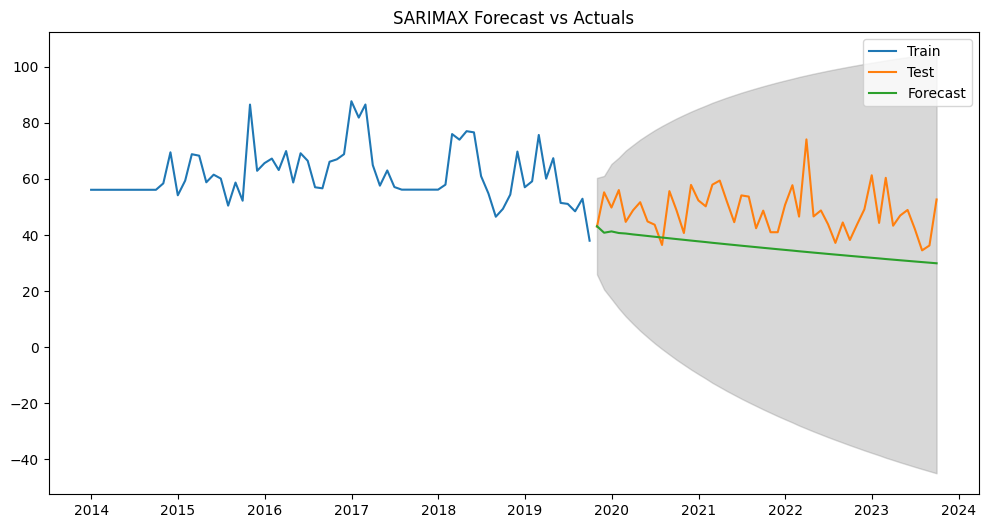

In [19]:
#SARIMAX MODEL

forecast = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_mean, label='Forecast')
plt.fill_between(test.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='gray', alpha=0.3)
plt.title('SARIMAX Forecast vs Actuals')
plt.legend()
plt.show()
#Ensure the train, test, and other variables are appropriately defined in your workspace, and adjust the above code accordingly.







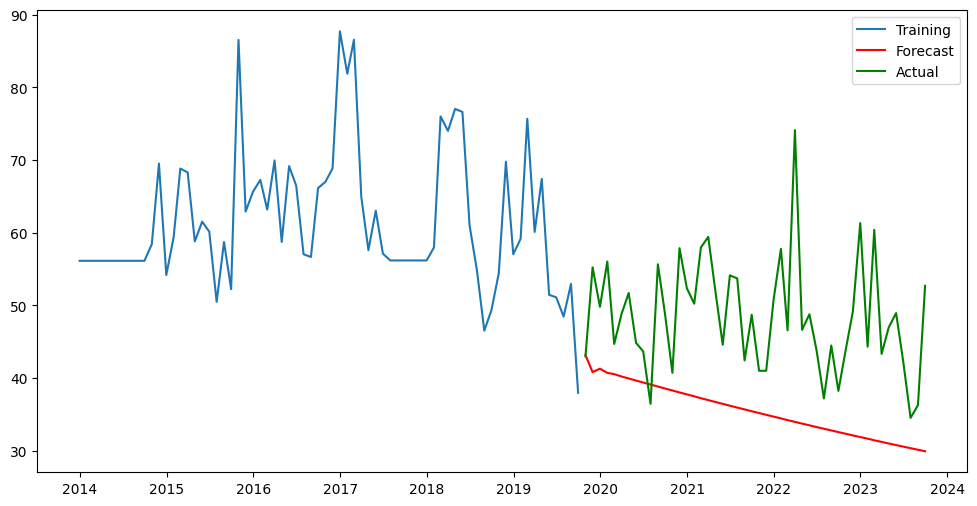

In [20]:
forecast = model_fit.forecast(steps=len(test))
plt.figure(figsize=(12,6))
plt.plot(train, label="Training")
plt.plot(test.index, forecast, label="Forecast", color='red')

plt.plot(test, label="Actual", color='green')
plt.legend()
plt.show()

In [21]:
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Squared Error (MSE): 231.6207534763806
Root Mean Squared Error (RMSE): 15.219091742820286


In [22]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(train)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.7172190121563564
p-value: 0.42226327176430606


TRYING NEW CODE

In [96]:
data = df[['o3']].copy().asfreq('M').dropna()

In [98]:
data.head()

,o3
date,
2013-12-31,26.47
2014-01-31,24.64
2014-02-28,18.07
2014-03-31,20.97
2014-04-30,23.40


<Axes: xlabel='date'>

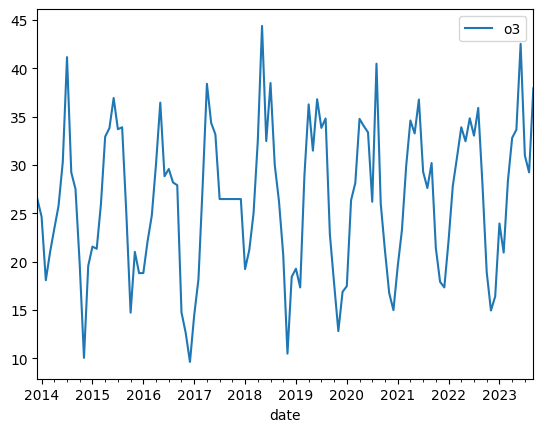

In [92]:
data.plot()

In [100]:
#Seasonal shift 
data['o3_seasonal']=data['o3']-data['o3'].shift(12)
data = data.dropna()
data.head(14)

,o3,o3_seasonal
date,,
2014-12-31,19.55,-6.92
2015-01-31,21.55,-3.09
2015-02-28,21.32,3.25
2015-03-31,25.94,4.97
2015-04-30,32.93,9.53
2015-05-31,33.81,8.04
2015-06-30,36.93,6.63
2015-07-31,33.70,-7.46
2015-08-31,33.90,4.67


In [101]:
p=d=q=range(0,2)
pdq=list(itertools.product(p,d,q))
seasonal_pdq=[(x[0],x[1],x[2],12)for x in pdq]



In [102]:
lowest_aic = float('inf')
best_pdq = None
best_seasonal_pdq = None

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = SARIMAX(data,
                          order=param,
                          seasonal_order=param_seasonal,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            
            results = mod.fit()
            
            if results.aic < lowest_aic:
                lowest_aic = results.aic
                best_pdq = param
                best_seasonal_pdq = param_seasonal

            print('SARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))
        
        except:
            continue

print('Best SARIMA{}x{}12 - AIC:{}'.format(best_pdq, best_seasonal_pdq, lowest_aic))


Best SARIMANonexNone12 - AIC:inf


In [ ]:
#0,0,1 and 1,1,1,12 are the best parameters for the model

In [103]:
#Check if data is stationary
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['o3_seasonal'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

#Pvalue is more than 0.05 DATA IS NON STATIONARY 

ADF Statistic: -3.578273
p-value: 0.006190
Critical Values:
	1%: -3.503
	5%: -2.893
	10%: -2.584


<Axes: xlabel='date'>

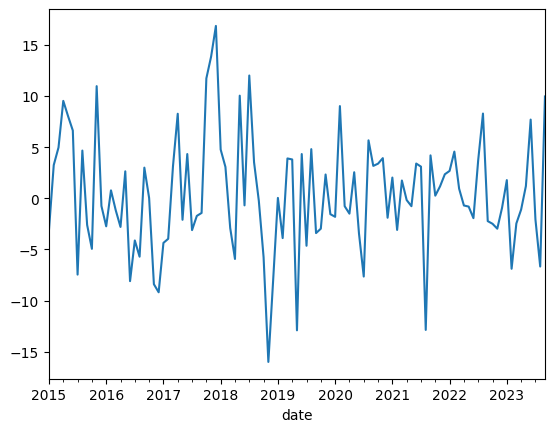

In [48]:
data['o3_seasonal'].plot()

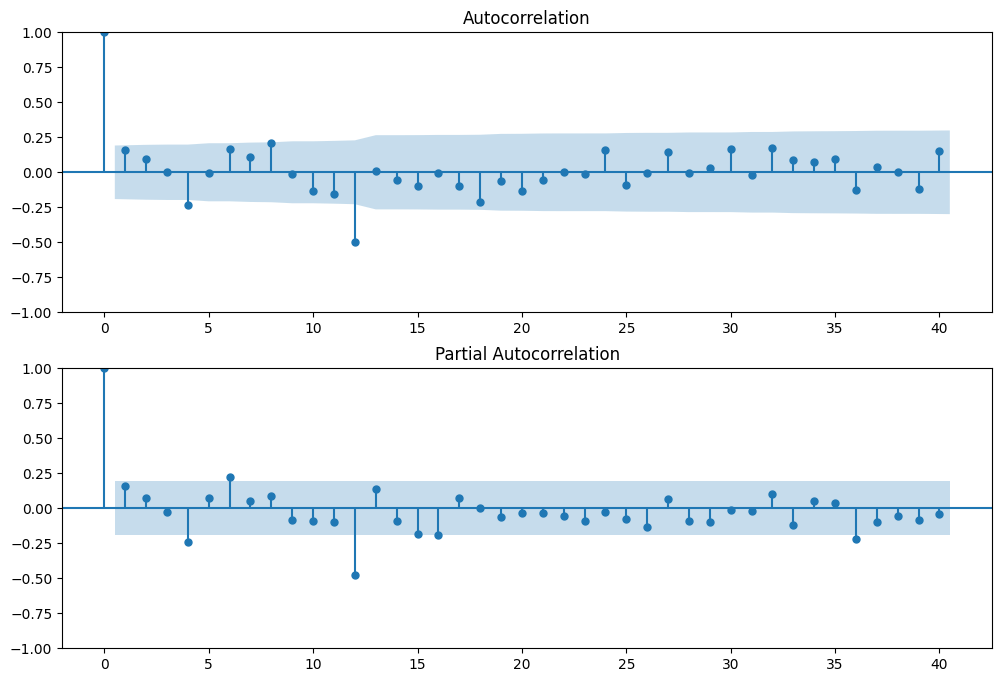

In [52]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = plot_acf(data['o3_seasonal'],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(data['o3_seasonal'],lags=40,ax=ax2)

In [24]:
best_model=SARIMAX(data['o3_seasonal'],order=(0,0,1),seasonal_order=(1,1,1,12))

results=best_model.fit()
print(results.summary().tables[1])

NameError: name 'data' is not defined

<Axes: xlabel='date'>

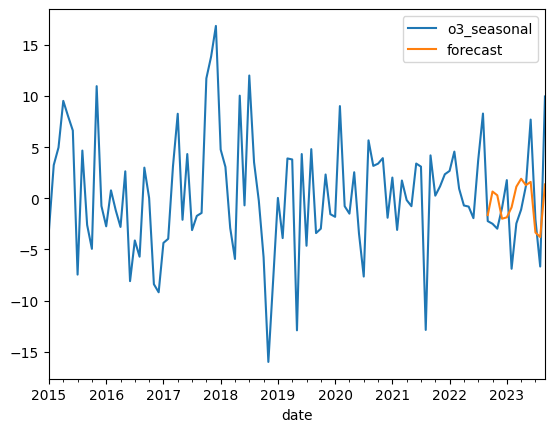

In [87]:
#data['forecast']=results.predict(start='2022-09-30',end='2023-09-30',dynamic=True)
#data[['o3_seasonal','forecast']].plot()

/var/folders/kr/m4s8zyfs4_xg9wqy_3tf3xxw0000gn/T/ipykernel_65112/459397434.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_data = pd.concat([data, forecast_df], axis=0)


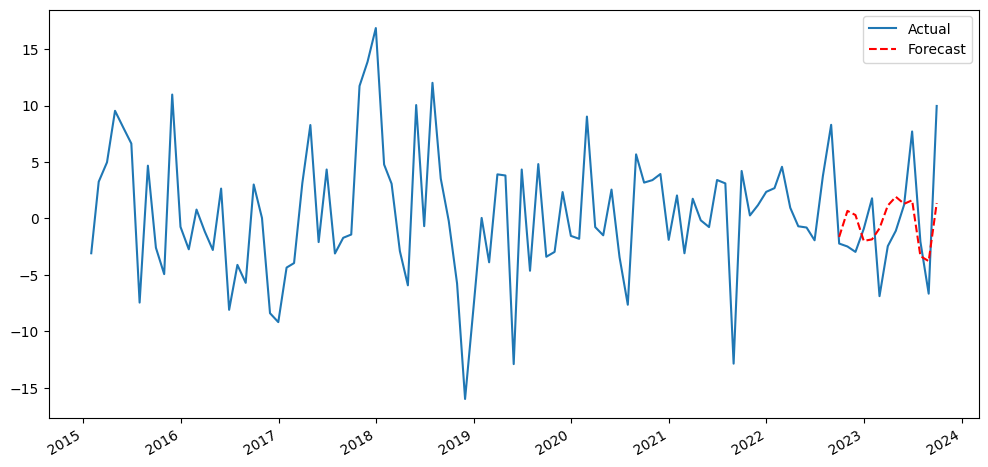

In [82]:
#LEAVING FOR NOW 
forecast_12_months = results.forecast(steps=12)

forecast_index = [data.index[-1] + pd.DateOffset(months=i) for i in range(1, 13)]
forecast_df = pd.DataFrame(forecast_12_months, index=forecast_index, columns=['forecast'])
combined_data = pd.concat([data, forecast_df], axis=0)
plt.figure(figsize=(12, 6))
combined_data['o3_seasonal'].plot(label='Actual')
combined_data['forecast'].plot(color='red', linestyle='dashed', label='Forecast')
plt.legend()
plt.show()

In [111]:
if forecast_values.isnull().any():
    print("The forecast contains NaN values. There might be an issue with the model or the data.")

           forecast
2023-10-31      NaN
2023-11-30      NaN
2023-12-31      NaN
2024-01-31      NaN
2024-02-29      NaN
2024-03-31      NaN
2024-04-30      NaN
2024-05-31      NaN
2024-06-30      NaN
2024-07-31      NaN
               o3  o3_seasonal forecast
2014-12-31  19.55        -6.92      NaN
2015-01-31  21.55        -3.09      NaN
2015-02-28  21.32         3.25      NaN
2015-03-31  25.94         4.97      NaN
2015-04-30  32.93         9.53      NaN
2015-05-31  33.81         8.04      NaN
2015-06-30  36.93         6.63      NaN
2015-07-31  33.70        -7.46      NaN
2015-08-31  33.90         4.67      NaN
2015-09-30  24.90        -2.60      NaN
2015-10-31  14.71        -4.94      NaN
2015-11-30  21.00        10.97      NaN
2015-12-31  18.80        -0.75      NaN
2016-01-31  18.81        -2.74      NaN
2016-02-29  22.10         0.78      NaN


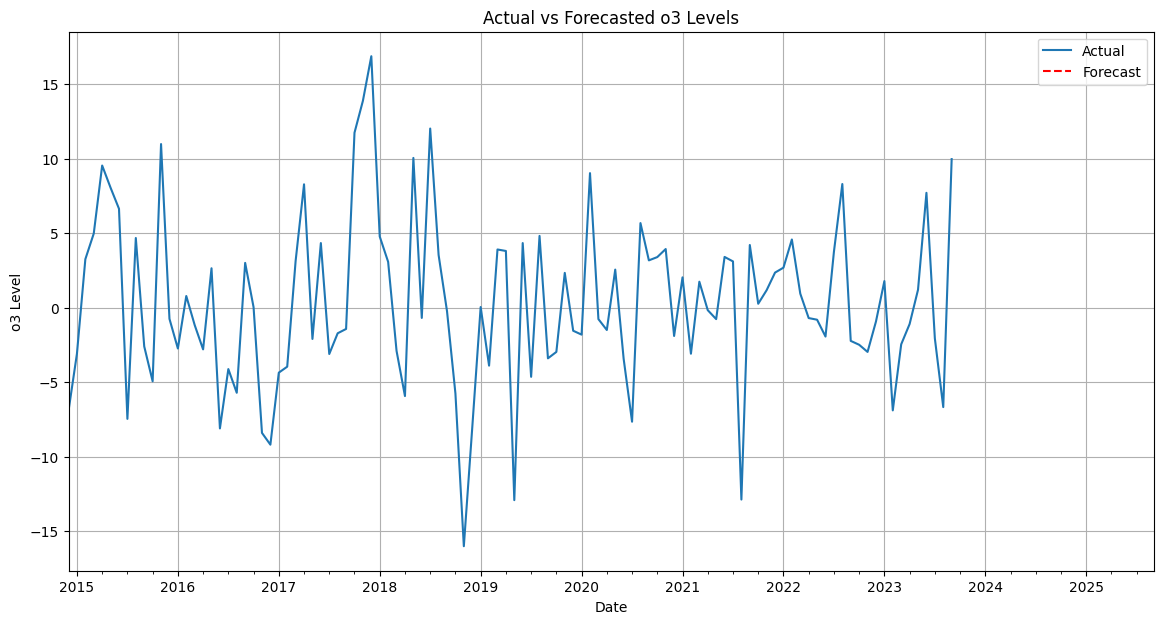

In [112]:
forecast_length = 24
forecast_values = results.get_forecast(steps=forecast_length).predicted_mean

# Create a new DataFrame for the forecasted values
forecast_index = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=forecast_length, freq='M')
forecast_df = pd.DataFrame(forecast_values, index=forecast_index, columns=['forecast'])
print(forecast_df.head(10))

# Combine the original data and the forecasted data
combined_data = pd.concat([data, forecast_df])

# Plot the actual and forecasted values
plt.figure(figsize=(14, 7))
combined_data['o3_seasonal'].plot(label='Actual')
combined_data['forecast'].plot(color='red', linestyle='dashed', label='Forecast')
print(combined_data.head(15))
plt.legend()
plt.title('Actual vs Forecasted o3 Levels')
plt.xlabel('Date')
plt.ylabel('o3 Level')
plt.grid(True)
plt.xlim(combined_data.index.min(), combined_data.index.max())
plt.show()



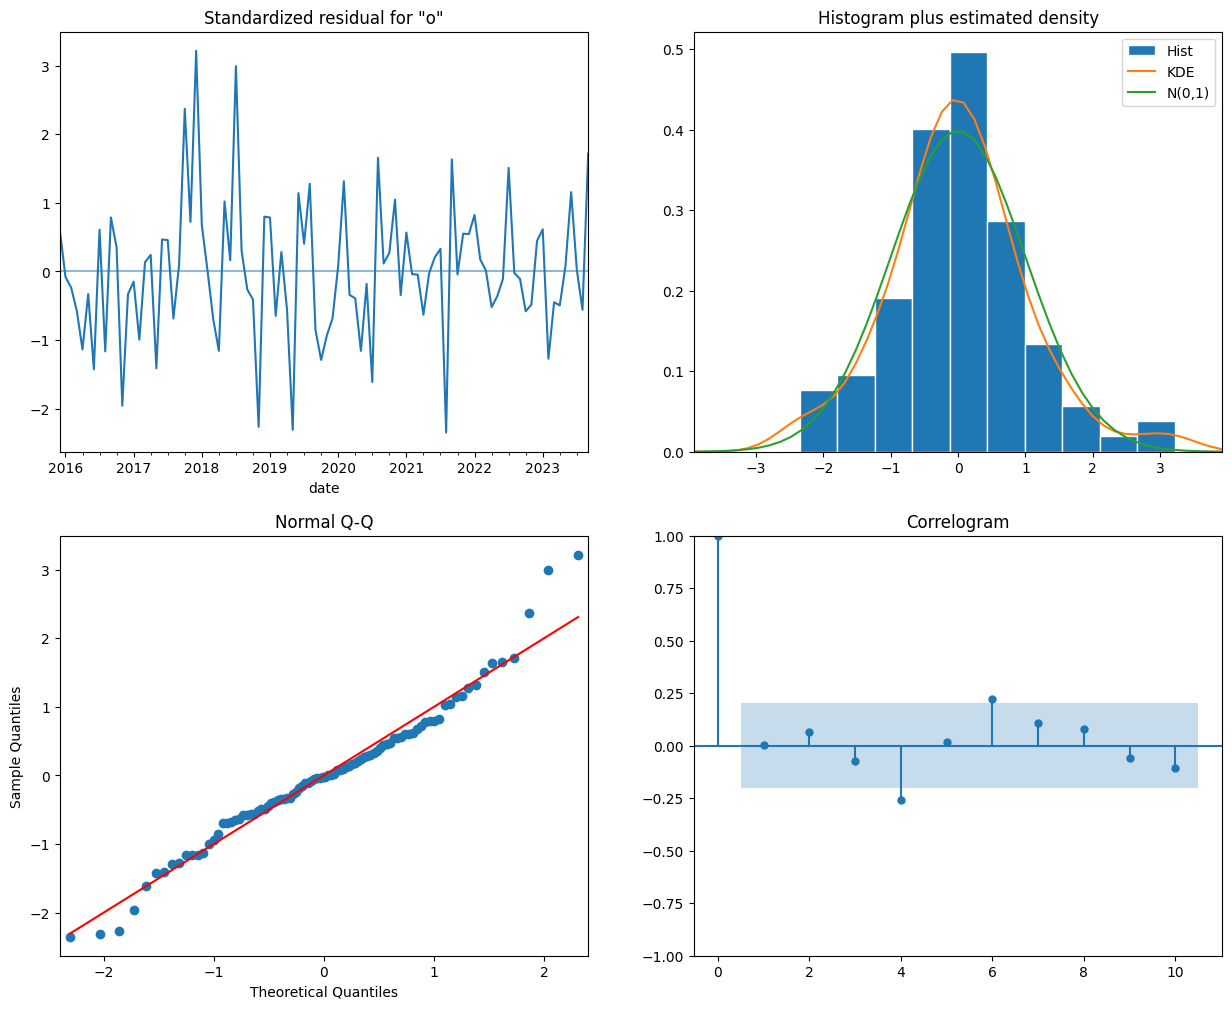

In [106]:
results.plot_diagnostics(figsize=(15, 12))
plt.show()

/var/folders/kr/m4s8zyfs4_xg9wqy_3tf3xxw0000gn/T/ipykernel_65112/1235346792.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_data = pd.concat([data, forecast_df], axis=0)


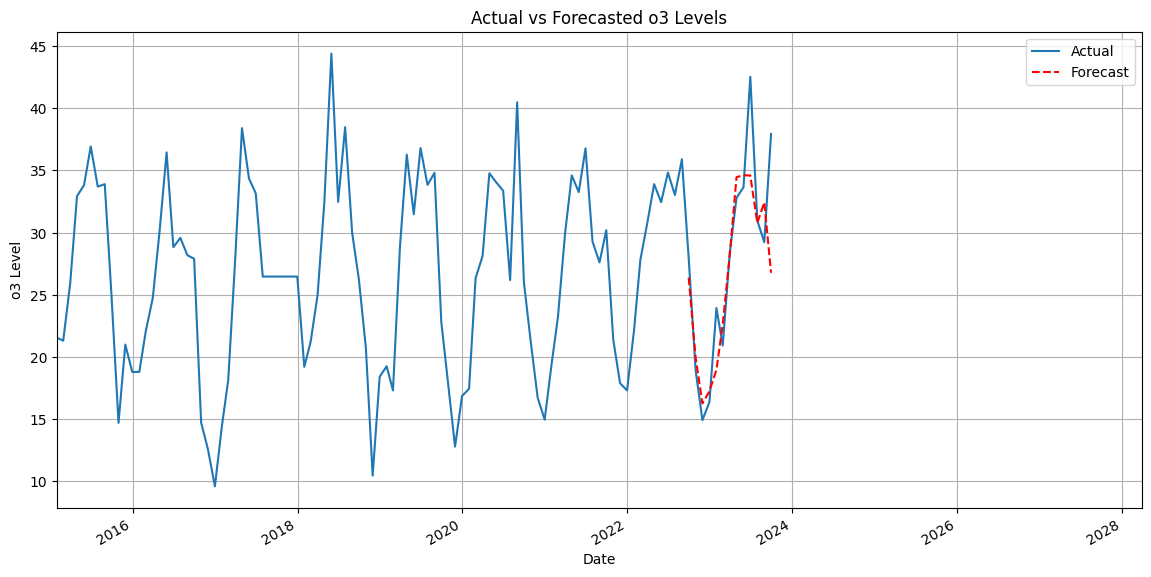

In [77]:
forecast_length = 54

# Generate the forecasted values
forecast_values = results.forecast(steps=forecast_length)

# Create a new DataFrame for the forecasted values
forecast_index = [data.index[-1] + pd.DateOffset(months=i) for i in range(1, forecast_length+1)]
forecast_df = pd.DataFrame(forecast_values, index=forecast_index, columns=['forecast'])

# Combine the original data and the forecasted data
combined_data = pd.concat([data, forecast_df], axis=0)

# Plot the actual and forecasted values
plt.figure(figsize=(14, 7))
combined_data['o3'].plot(label='Actual')
combined_data['forecast'].plot(color='red', linestyle='dashed', label='Forecast')
plt.legend()
plt.title('Actual vs Forecasted o3 Levels')
plt.xlabel('Date')
plt.ylabel('o3 Level')
plt.grid(True)

# Ensure the x-axis covers the full date range
plt.xlim(combined_data.index.min(), combined_data.index.max())

plt.show()

In [78]:
combined_data.head()

,o3,o3_shift,o3_seasonal,forecast
2015-01-31,21.55,2.00,-3.09,NaN
2015-02-28,21.32,-0.23,3.25,NaN
2015-03-31,25.94,4.62,4.97,NaN
2015-04-30,32.93,6.99,9.53,NaN
2015-05-31,33.81,0.88,8.04,NaN


<MonthEnd>


In [67]:
print(data.index[-1])

2023-09-30 00:00:00


In [68]:
from pandas.tseries.offsets import DateOffset
future_dates=[data.index[-1]+ DateOffset(months=x)for x in range(0,24)]
future_dates_df=pd.DataFrame(index=future_dates[1:],columns=data.columns)
future_df = pd.concat([data, future_dates_df])
forecasted_values = results.forecast(steps=24)
future_df.loc[forecasted_values.index, 'forecast'] = forecasted_values.values
future_df[['o3', 'forecast']].plot(figsize=(12, 8))

/var/folders/kr/m4s8zyfs4_xg9wqy_3tf3xxw0000gn/T/ipykernel_65112/3159529201.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  future_df = pd.concat([data, future_dates_df])


KeyError: "[Timestamp('2023-10-31 00:00:00'), Timestamp('2023-12-31 00:00:00'), Timestamp('2024-01-31 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2024-05-31 00:00:00'), Timestamp('2024-07-31 00:00:00'), Timestamp('2024-08-31 00:00:00'), Timestamp('2024-10-31 00:00:00'), Timestamp('2024-12-31 00:00:00'), Timestamp('2025-01-31 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2025-05-31 00:00:00'), Timestamp('2025-07-31 00:00:00'), Timestamp('2025-08-31 00:00:00'), Timestamp('2025-09-30 00:00:00')] not in index"

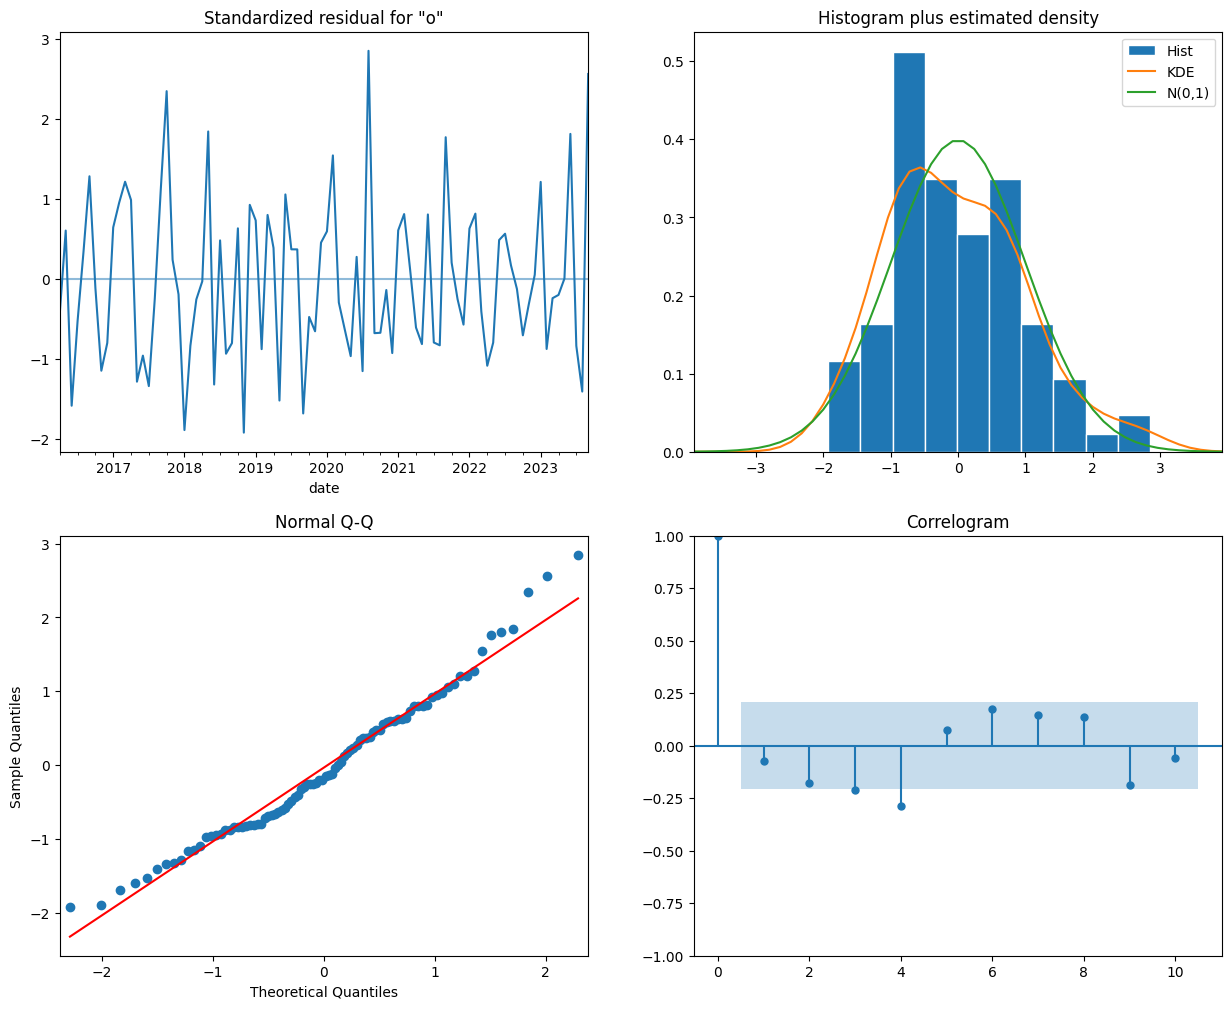

In [17]:
results.plot_diagnostics(figsize=(15,12))
plt.show()

In [24]:
pred=results.get_prediction(start=pd.to_datetime('2023-10-30'),end=pd.to_datetime('2025-12-31'),dynamic=False)
pred_ci=pred.conf_int()
pred_ci

,lower o3,upper o3
2023-10-31,-22.380236,-3.121499
2023-11-30,-11.366546,9.494604
2023-12-31,-10.763802,10.446889
2024-01-31,-7.024263,14.224726
2024-02-29,-7.249835,14.018797
2024-03-31,-5.076582,16.190371
2024-04-30,-5.098778,16.170201
2024-05-31,-10.593069,10.675277
2024-06-30,-8.891426,12.377230
2024-07-31,-14.686160,6.582396


In [27]:
y_forecasted=pred.predicted_mean
y_truth=data['2023-09-30':]
y_truth['Pred_val']=y_forecasted
y_truth

/var/folders/kr/m4s8zyfs4_xg9wqy_3tf3xxw0000gn/T/ipykernel_65112/4089852312.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_truth['Pred_val']=y_forecasted


,o3,Pred_val
date,,
2023-09-30,8.7,NaN


!TRYING PROPHET MODEL

In [122]:
prophet_df=df[['o3']].copy().asfreq('M').dropna()
prophet_df = prophet_df.reset_index().rename(columns={'date': 'ds', 'o3': 'y'})

In [123]:
prophet_df.head()

,ds,y
0,2013-12-31,26.47
1,2014-01-31,24.64
2,2014-02-28,18.07
3,2014-03-31,20.97
4,2014-04-30,23.40


In [126]:
from prophet import Prophet
m = Prophet()
m.fit(prophet_df)

/Users/rheagupta/Documents/x6/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
13:27:23 - cmdstanpy - INFO - Chain [1] start processing
13:27:23 - cmdstanpy - INFO - Chain [1] done processing


In [139]:
#Predict
future = m.make_future_dataframe(periods=48, freq='M')
forecast = m.predict(future)

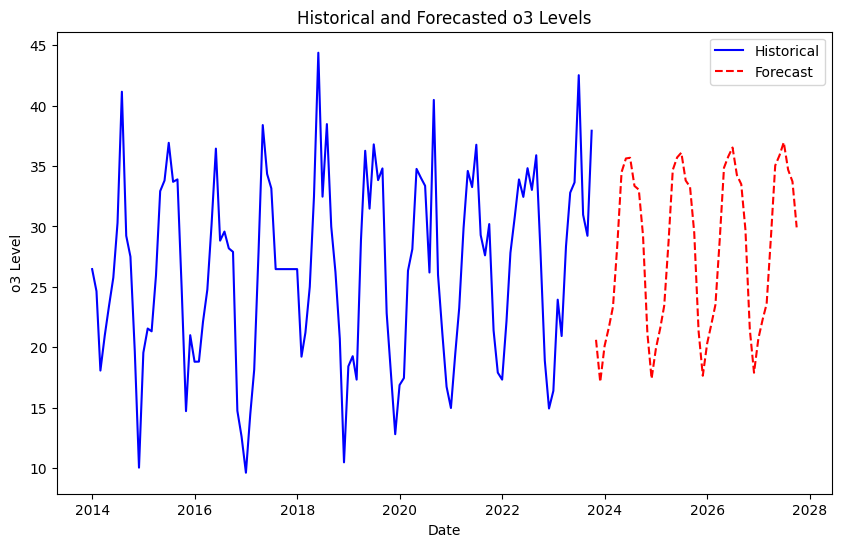

In [140]:
plt.figure(figsize=(10, 6))
plt.plot(prophet_df['ds'], prophet_df['y'], label='Historical', color='blue')
forecasted = forecast[forecast['ds'] > prophet_df['ds'].max()]
plt.plot(forecasted['ds'], forecasted['yhat'], label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('o3 Level')
plt.title('Historical and Forecasted o3 Levels')
plt.legend()
plt.show()

/Users/rheagupta/Documents/x6/.venv/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/Users/rheagupta/Documents/x6/.venv/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/Users/rheagupta/Documents/x6/.venv/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime o

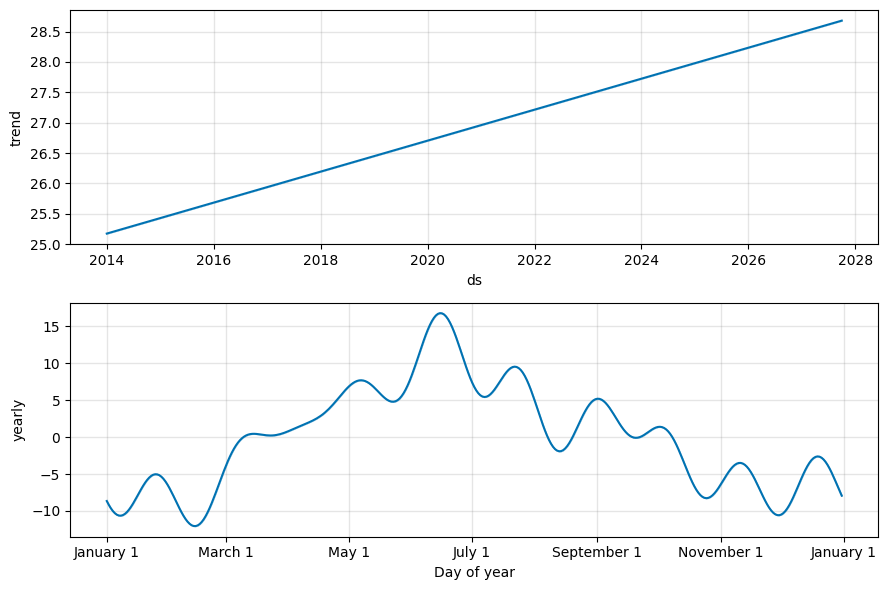

In [141]:
fig2 = m.plot_components(forecast)

In [142]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2013-12-31,17.247748,12.784366,22.007315
1,2014-01-31,18.902556,13.784597,23.818373
2,2014-02-28,20.457757,15.419683,25.561275
3,2014-03-31,25.908915,21.045308,30.974434
4,2014-04-30,31.801577,26.772289,36.743163


In [153]:
target_year = 2027
target_month = 8
forecasted_value_row = forecast[(forecast['ds'].dt.year == target_year) & (forecast['ds'].dt.month == target_month)]
forecasted_value_row['yhat']

164    33.72244
Name: yhat, dtype: float64